<a href="https://colab.research.google.com/github/TebogoLesedi1/AI-Powered-GBV-Hotspot-Prediction-And-Support-System/blob/main/iris_dataset_for_data_science_pratice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 1: Import Required Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

#
from sklearn.model_selection import train_test_split

#preprocessing
from sklearn.preprocessing import StandardScaler

#import all the classification model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier



#evaluation matrics
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix,
ConfusionMatrixDisplay,
roc_curve,
auc,
roc_auc_score
)


Step 2: Load the Iris Dataset
The Iris dataset contains 150 observations belonging to three flower species:
Setosa
Versicolor
Virginica
Each observation contains four numerical features.

In [23]:
iris = load_iris()
print("feature names:")
print(iris.feature_names)
print("\nterget namees:")
print(iris.target_names)

feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

terget namees:
['setosa' 'versicolor' 'virginica']


Step 3: Convert the Dataset into a Pandas DataFrame

In [24]:
df = pd.DataFrame(
iris.data,
columns=iris.feature_names
)
# Add numerical target
df["target"] = iris.target
# Add readable species names
df["species"] = df["target"].map({
0: "setosa",
1: "versicolor",
2: "virginica"
})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Step 4: Examine the Dataset

In [25]:
#view the data points in at the top
df.head()



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [26]:
#view the data points in at the top
df.tail()



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [27]:

#data demisions
df.shape


(150, 6)

In [28]:


df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'species'],
      dtype='object')

Step 5: Examine Data Types

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Step 6: Descriptive Statistics

In [30]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Step 7: Check Data Quality
7.1 Check Missing Values

In [31]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
species,0


7.2 Check Duplicate Records

In [32]:
df.duplicated().sum()

np.int64(1)

If desired, duplicate observations can be removed using:

In [33]:
df = df.drop_duplicates()

Step 8: Examine Class Distribution


species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64


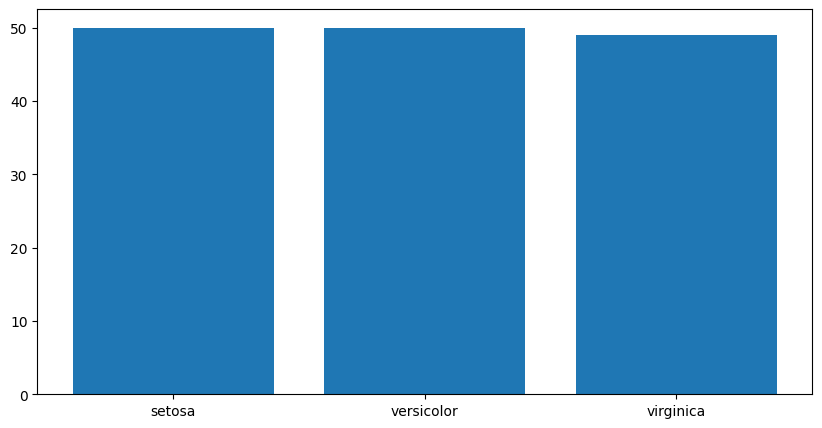

In [34]:
print(df["species"].value_counts())

species_count = df["species"].value_counts()

plt.figure(figsize = (10,5))
plt.bar(
species_count.index,
species_count.values
)

plt.xlabel("")
plt.ylabel("")
plt.title("")

plt.show()

Step 9: Exploratory Data Analysis

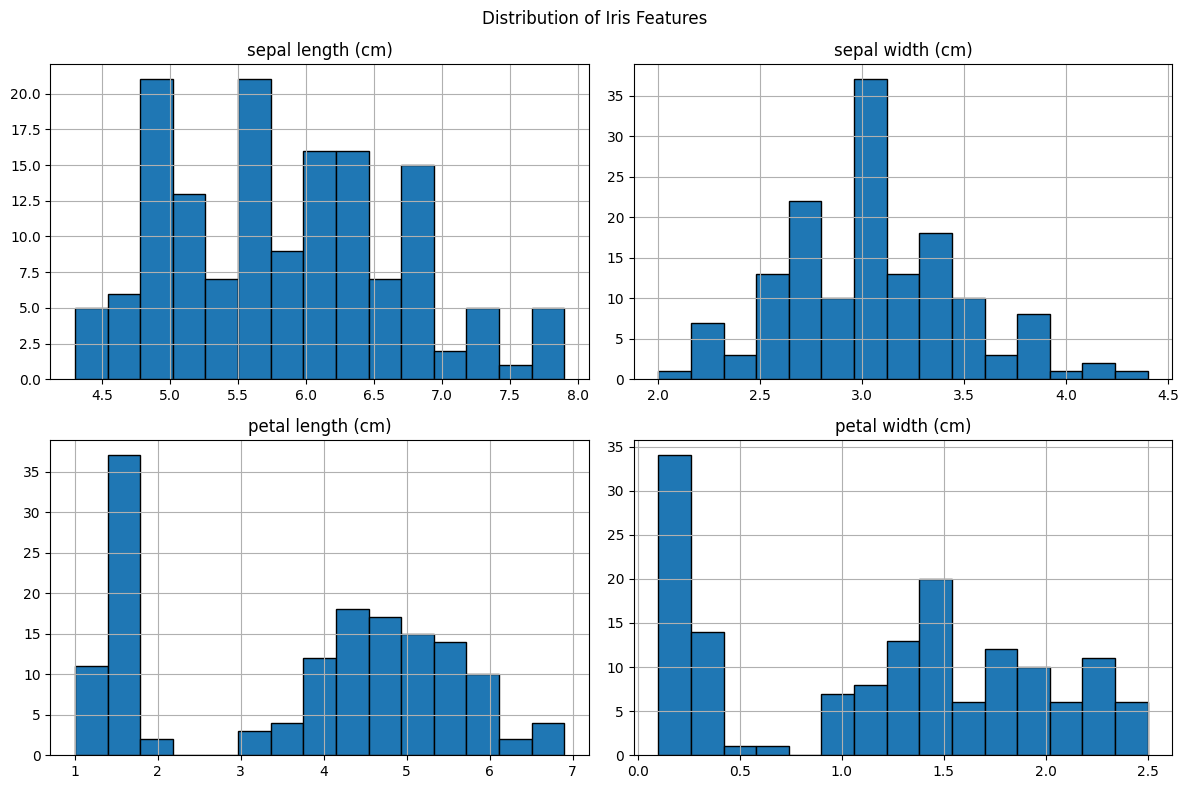

In [35]:
#histogram

features = iris.feature_names
df[features].hist(
figsize=(12, 8),
bins=15,
edgecolor="black"
)
plt.suptitle("Distribution of Iris Features")
plt.tight_layout()
plt.show()

Step 10: Scatter Plot – Sepal Length vs Sepal Width

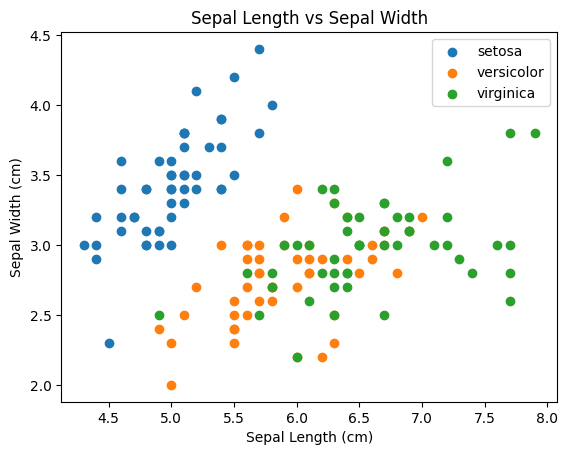

In [36]:
plt.figsize = (10,5)

for species in df["species"].unique():
  df_species = df[df["species"] == species]
  plt.scatter(
      df_species["sepal length (cm)"],
      df_species["sepal width (cm)"],
      label = species)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Sepal Length vs Sepal Width")
plt.legend()
plt.show()


Step 11: Scatter Plot – Petal Length vs Petal Width

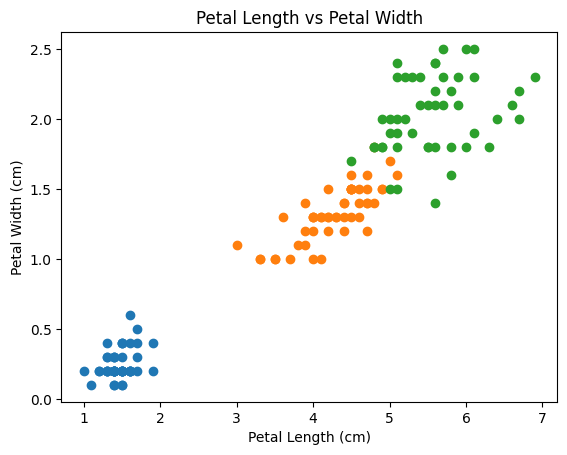

In [37]:
plt.figsize = (10, 6)
for species in df["species"].unique():
  df_species = df[df["species"] == species]
  plt.scatter(
      df_species["petal length (cm)"],
      df_species["petal width (cm)"],
      label=species
  )
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.legend

plt.show()

Step 12: Scatter Matrix

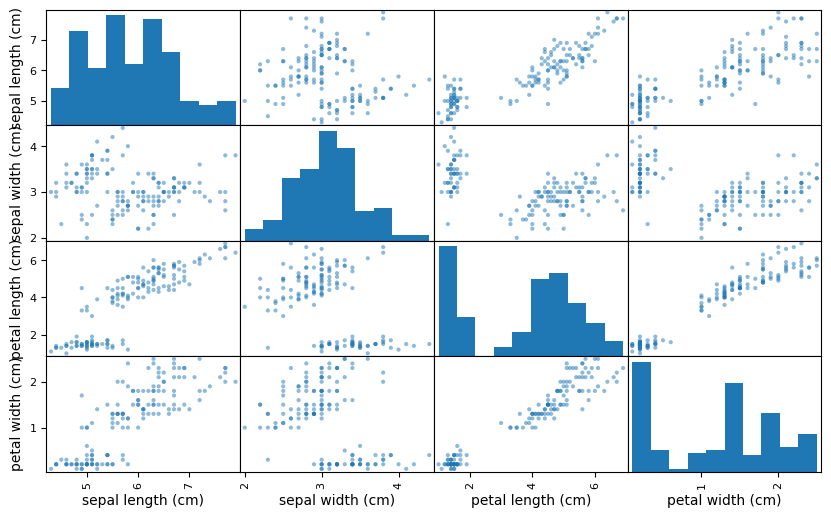

In [38]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    df[iris.feature_names],
    figsize=(10,6),
    diagonal = "hist"

)

plt.suptitle("")

plt.show()

Step 14: Separate Features and Target
The predictor variables are stored in X , while the class variable is stored in y

In [39]:
X = df[iris.feature_names]
y = df["target"]

print(X.shape)
print(X.shape)

(149, 4)
(149, 4)


Step 15: Split the Dataset into Training and Testing Sets

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)
print("X_train shape", X_train.shape)

X_train shape (119, 4)


Step 16: Standardise the Features
Feature scaling is especially important for algorithms such as:
Logistic Regression

KNN

SVM

Neural Networks

Importantly, the scaler is fitted only on the training data to avoid data leakage.


In [41]:
scaler = StandardScaler()
X_tarin_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 17: Define the Classification Models

In [42]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter = 1000,
        random_state = 42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors = 5
    ),
    "SVM": SVC(
        probability = True,
        random_state = 42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state = 42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state = 42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators = 1000,
        random_state = 42
    ),
    "Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter = 1000,
        random_state = 42
    )
}

Step 18: Train All Classification Models

In [43]:
trained_models = {}

for name, model in models.items():

  print("training",name)
  model.fit(
      X_tarin_scaled,
      y_train
  )
  trained_models[name] = model

training Logistic Regression
training KNN
training SVM
training Decision Tree
training Gradient Boosting
training Random Forest
training Naive Bayes
training Neural Network


Step 19: Generate Predictions

In [45]:
predictions = {}

for name, model in models.items():
  y_pred = model.predict(X_test_scaled)
  predictions[name] = y_pred

  print(name)
  print(y_pred)


Logistic Regression
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
KNN
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
SVM
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Decision Tree
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Gradient Boosting
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Random Forest
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Naive Bayes
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Neural Network
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


Step 20: Evaluate Model Accuracy

In [48]:
for name, y_pred in predictions.items():
  accuracy = accuracy_score(
      y_test,
      y_pred
  )
  print(
  f"{name}: {accuracy:.4f}")

Logistic Regression: 1.0000
KNN: 1.0000
SVM: 1.0000
Decision Tree: 1.0000
Gradient Boosting: 1.0000
Random Forest: 1.0000
Naive Bayes: 1.0000
Neural Network: 1.0000


Step 21: Calculate Multiple Performance Metrics
For multiclass classification, we use the weighted average for Precision, Recall and F1-
score

In [ ]:
result = []
for name, y_pred in predictions.item():
  accuracy = accuracy_score(
      y_test,
      y_pred
  )
  precision = precision_score(
      y_test,
      y_pred,
      average = "weighted"
  )
  recall = recall_score(
      y_test,
      y_pred,
      average = "weighted"
  )
  f1 = f1_score(
      y_test,
      y_pred,
      average = "weighted"
  )
  result.append(
      [name, accuracy, precision, recall, f1]
  )

  results_df = pd_DataFrame(
      results,
      columns =
  )